In [ ]:
from openpiv import windef
from openpiv import tools, scaling, validation, filters, preprocess
import openpiv.pyprocess as process
from openpiv import pyprocess
import numpy as np
import pathlib
from time import time
import warnings
import tifffile as tif


import matplotlib.pyplot as plt
%matplotlib inline  

Saving to /mnt/crunch/Clark/Larva/Larva 4.0 (7-5-26)/results/OpenPIV_results_32_my_run/field_A0000.txt


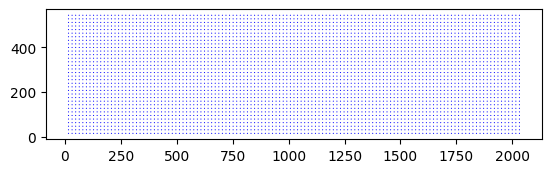

Image Pair 1
Rolling_Balled reference-rolling_Stack


In [ ]:
settings = windef.PIVSettings()

data_path = '/mnt/crunch/Clark/Larva/Larva 4.0 (7-5-26)/'
reference_stack = 'Rolling_Balled.tif'
deformed_stack = 'reference-rolling_Stack.tif'

# Change image settings to your own data
settings.filepath_images = pathlib.Path(data_path)
settings.save_path = pathlib.Path(data_path)
settings.save_folder_suffix = 'my_run'
settings.frame_pattern_a = reference_stack   # Adjust to your naming
settings.frame_pattern_b = deformed_stack   # Adjust to your naming

settings.roi = 'full'
settings.dynamic_masking_method = 'None'

settings.deformation_method = 'symmetric'
settings.correlation_method = 'circular'
settings.normalized_correlation = False

# Multipass FFT settings
settings.num_iterations = 2
settings.windowsizes = (64, 32, 16)   # Coarse -> fine
settings.overlap = (32, 16, 8)        # 50% overlap at each pass
settings.subpixel_method = 'gaussian'
settings.interpolation_order = 3
settings.scaling_factor = 1
settings.dt = 1

settings.sig2noise_method = 'peak2peak'
settings.sig2noise_mask = 2

settings.validation_first_pass = True
settings.min_max_u_disp = (-200, 200)
settings.min_max_v_disp = (-200, 200)
settings.std_threshold = 1000
settings.median_threshold = 1000
settings.median_size = 1000
settings.sig2noise_threshold = 0

settings.replace_vectors = True
settings.smoothn = True
settings.smoothn_p = 0.5
settings.filter_method = 'localmean'
settings.max_filter_iteration = 4
settings.filter_kernel_size = 2

settings.save_plot = False
settings.show_plot = True
settings.scale_plot = 200

windef.piv(settings)

frame_a shape: (571, 2048) dtype: float64
frame_b shape: (571, 2048) dtype: float64
frame_a min/max: 173.06199999999998 262.65
frame_b min/max: 171.16899999999998 262.65


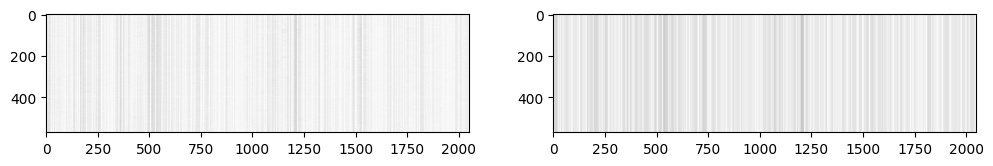

In [9]:
from openpiv import tools
import numpy as np

frame_a = tools.imread(settings.filepath_images / settings.frame_pattern_a)
frame_b = tools.imread(settings.filepath_images / settings.frame_pattern_b)

print("frame_a shape:", frame_a.shape, "dtype:", frame_a.dtype)
print("frame_b shape:", frame_b.shape, "dtype:", frame_b.dtype)
print("frame_a min/max:", frame_a.min(), frame_a.max())
print("frame_b min/max:", frame_b.min(), frame_b.max())

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12,6))
ax[0].imshow(frame_a, cmap='gray')
ax[1].imshow(frame_b, cmap='gray')
plt.show()

In [11]:
# ok what the fuck, check
import tifffile as tif

data_path = '/mnt/crunch/Clark/Larva/Larva 4.0 (7-5-26)/'
reference_stack_path = data_path + 'Rolling_Balled.tif'
deformed_stack_path = data_path + 'reference-rolling_Stack.tif'

reference_stack = tif.imread(reference_stack_path)
deformed_stack = tif.imread(deformed_stack_path)

print(reference_stack.shape, "dtype:", reference_stack.dtype)
print(deformed_stack.shape, "dtype:", deformed_stack.dtype)

(571, 2048, 2048) dtype: uint8
(571, 2048, 2048) dtype: uint8


u range: -25.9010415306365 27.57285697458599
v range: -31.2957681263109 27.107486733504913


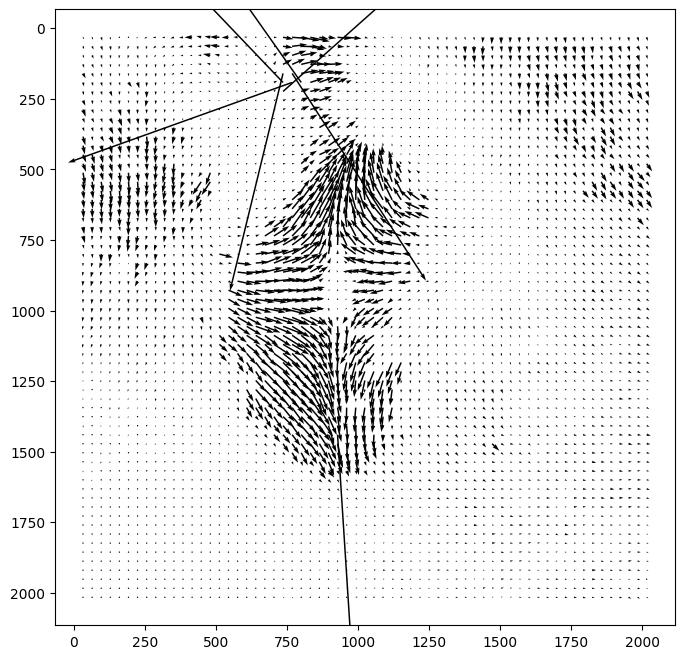

In [15]:
import numpy as np
from openpiv import windef

frame_a = reference_stack[0].astype(np.int32)
frame_b = deformed_stack[0].astype(np.int32) 

x, y, u, v, sig2noise = windef.first_pass(frame_a, frame_b, settings)

print('u range:', np.nanmin(u), np.nanmax(u))
print('v range:', np.nanmin(v), np.nanmax(v))

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.quiver(x, y, u, v)
plt.gca().invert_yaxis()
plt.show()